In [1]:
#install required packages
%pip install xgboost -q


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

from xgboost import XGBRegressor


In [3]:
#Loading the dataset
df = pd.read_csv("data/charging_ev_and_grid_optimization_dataset.csv")

print(df.shape)

df.head()

(8354, 27)


,timestamp,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,...,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
0,1/1/2025 0:00,ST004,Urban,EV10000,Two-Wheeler,1/1/2025 0:00,1/1/2025 0:12,1/1/2025 4:33,12,60,...,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,CH4,Low,-8.622299
1,1/1/2025 0:15,ST005,Urban,EV10001,Two-Wheeler,1/1/2025 0:15,1/1/2025 0:23,1/1/2025 1:12,8,100,...,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,CH9,Low,-1.935644
2,1/1/2025 0:30,ST019,Highway,EV10002,Car,1/1/2025 0:30,1/1/2025 0:41,1/1/2025 1:35,11,75,...,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,CH2,Low,-18.201846
3,1/1/2025 0:45,ST008,Urban,EV10003,Two-Wheeler,1/1/2025 0:45,1/1/2025 0:54,1/1/2025 3:29,9,40,...,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,CH9,Medium,-7.404018
4,1/1/2025 1:00,ST008,Highway,EV10004,Two-Wheeler,1/1/2025 1:00,1/1/2025 1:08,1/1/2025 6:14,8,75,...,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,CH1,Low,-6.577466


In [4]:
#Preprocess the data
df = df.drop_duplicates()

print("Missing values")

print(df.isnull().sum())

df['timestamp'] = pd.to_datetime(df['timestamp'])

df.info()
df.describe()

Missing values
timestamp                 0
station_id                0
location_type             0
vehicle_id                0
vehicle_type              0
arrival_time              0
charging_start_time       0
charging_end_time         0
waiting_time              0
battery_capacity_kWh      0
initial_soc               0
final_soc                 0
energy_consumed_kWh       0
charging_power_kW         0
charging_duration         0
queue_length              0
station_load              0
electricity_price         0
renewable_energy_ratio    0
traffic_density           0
weather_condition         0
day_of_week               0
time_slot                 0
charging_demand           0
assigned_charger_id       0
charging_priority         0
optimization_reward       0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 8354 entries, 0 to 8353
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         


,timestamp,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,charging_duration,queue_length,station_load,electricity_price,renewable_energy_ratio,charging_demand,optimization_reward
count,8354,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000
mean,2025-02-13 12:07:30,9.526335,61.079722,34.808452,98.495545,39.079746,22.449126,178.700376,4.591573,53.177399,9.959945,0.354101,53.156126,-11.834559
min,2025-01-01 00:00:00,0.000000,30.000000,10.000582,65.079759,7.502195,7.000000,10.000000,0.000000,10.053024,5.000000,0.100157,5.505723,-43.285910
25%,2025-01-22 18:03:45,6.000000,40.000000,22.371986,98.463666,23.675251,11.000000,64.118008,3.000000,28.029710,7.510000,0.207315,27.911603,-18.354606
50%,2025-02-13 12:07:30,9.000000,60.000000,34.638994,99.998223,35.148384,11.000000,133.700252,5.000000,49.421293,9.955000,0.313459,49.513337,-11.268337
75%,2025-03-07 06:11:15,13.000000,75.000000,47.310647,100.000000,51.363447,22.000000,247.946169,7.000000,77.600445,12.397500,0.462315,77.845036,-5.106912
max,2025-03-29 00:15:00,28.000000,100.000000,59.992462,100.000000,89.929089,50.000000,776.551110,15.000000,100.000000,15.000000,0.799922,104.985659,14.176434
std,NaN,4.894049,25.001163,14.478839,3.258039,18.973883,16.813449,149.120567,2.828987,27.380740,2.878798,0.186150,27.563387,9.271940


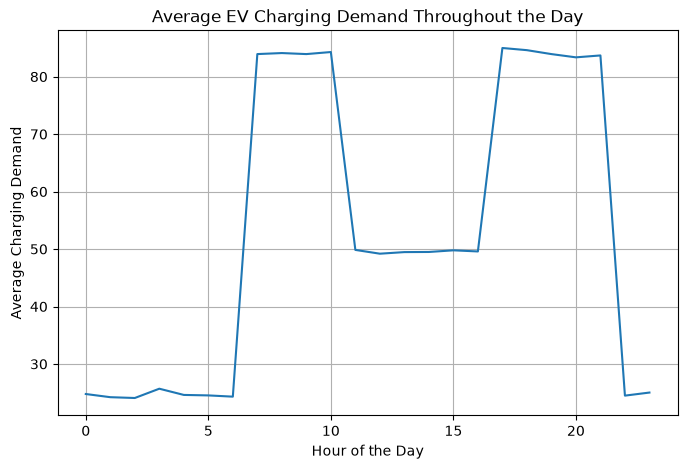

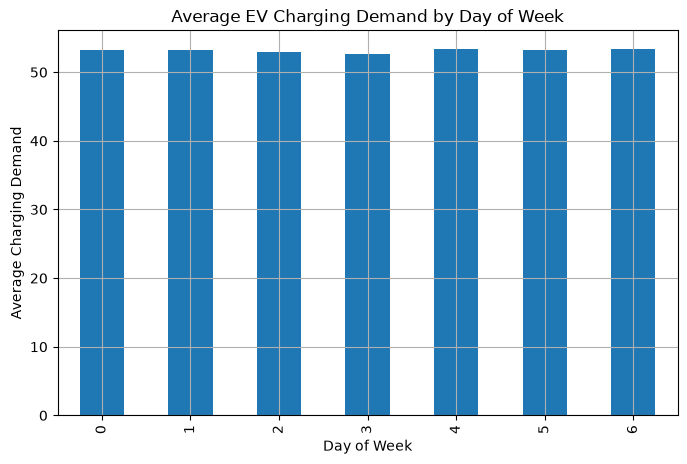

In [5]:
#Expolatory data analysis
hourly_demand = df.groupby(df['timestamp'].dt.hour)['charging_demand'].mean()

daily_demand = df.groupby(df['timestamp'].dt.day_of_week)['charging_demand'].mean()
#Graph 1
plt.figure(figsize=(8,5))

hourly_demand.plot()

plt.title('Average EV Charging Demand Throughout the Day')

plt.xlabel('Hour of the Day')

plt.ylabel('Average Charging Demand')

plt.grid(True)

plt.show()

#Graph 2
plt.figure(figsize=(8,5))

daily_demand.plot(kind='bar')

plt.title('Average EV Charging Demand by Day of Week')

plt.xlabel('Day of Week')

plt.ylabel('Average Charging Demand')

plt.grid(True)

plt.show()

In [6]:
#Feature engineering
df['hour'] = df['timestamp'].dt.hour
df['month'] = df['timestamp'].dt.month

df['is_weekend'] = df['day_of_week'].isin( ['Saturday', 'Sunday']).astype(int)
df['peak_hour'] = df['hour'].apply(lambda x: 1 if x in [7,8,9,17,18,19,20] else 0)

In [7]:
#Encode columns
label_columns = [
    'weather_condition',
    'day_of_week',
    'location_type',
    'vehicle_type',
    'traffic_density',
    
    
]

encoders = {}

for col in label_columns:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  encoders[col] = le

# K-Means

In [48]:
# K-Means

persona_features = [
    'charging_duration',
    'energy_consumed_kWh',
    'initial_soc',
    'final_soc',
    'waiting_time',
    'charging_power_kW',
    'hour',
    'location_type',
    'is_weekend',
    'vehicle_type'
]

persona_df = df[persona_features]
x = StandardScaler()
y_means = x.fit_transform(persona_df)


In [84]:
import joblib
joblib.dump(x, "models/persona_scaler.pkl")
print("Persona scaler saved successfully")

Persona scaler saved successfully


In [49]:
# Elbow method
inertia = []
for k in range(2,10):
  km = KMeans(n_clusters=k, random_state=42)
  km.fit(y_means)
  inertia.append(km.inertia_)



In [50]:
inertia

[71989.44911034011,
 65884.56122329492,
 60107.35293106846,
 55110.65353282234,
 52491.07480909977,
 50859.07298256972,
 48747.205230789485,
 47378.72590242343]

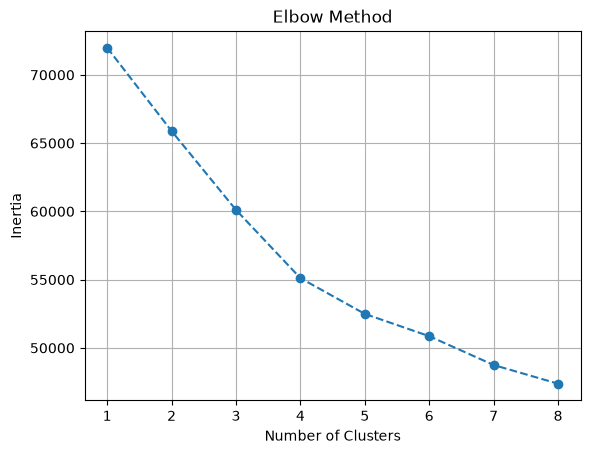

In [51]:
# Plot Elbow graph
#plt.figure(figsize=(8,5))

plt.plot(range(1,9), inertia, marker='o', linestyle='--')

plt.title('Elbow Method')

plt.xlabel('Number of Clusters')

plt.ylabel('Inertia')

plt.grid(True)

plt.show()

In [52]:
# Final K- Means with k=4
kmeans = KMeans(n_clusters=4, random_state=42)
df['persona'] = kmeans.fit_predict(y_means)
df['persona']

0       1
1       1
2       1
3       1
4       3
       ..
8349    2
8350    1
8351    3
8352    0
8353    0
Name: persona, Length: 8354, dtype: int32

In [83]:
import joblib

joblib.dump(kmeans, "models/kmeans.pkl")
print("KMeans model saved successfully")

KMeans model saved successfully


In [54]:
df['persona'].value_counts()

persona
1    4001
3    1926
0    1867
2     560
Name: count, dtype: int64

In [55]:
persona_summary = df.groupby('persona')[[
    'charging_duration',
    'energy_consumed_kWh',
    'initial_soc',
    'final_soc',
    'waiting_time',
    'charging_power_kW',
    'hour',
    'location_type',
    'is_weekend',
    'vehicle_type'
]].mean()

persona_summary

,charging_duration,energy_consumed_kWh,initial_soc,final_soc,waiting_time,charging_power_kW,hour,location_type,is_weekend,vehicle_type
persona,,,,,,,,,,
0,139.314951,35.289505,36.706225,99.040540,9.601500,22.956615,11.392073,0.509909,1.000000,0.995179
1,120.930745,32.055391,38.786493,99.101686,9.479880,24.002000,11.434391,0.491377,0.000000,0.987503
2,35.166186,25.661489,34.984820,88.675473,10.083929,45.641071,12.067857,0.505357,0.223214,1.037500
3,378.621469,61.247475,24.653700,99.563335,9.387850,11.988058,11.563863,0.512461,0.163032,1.020249


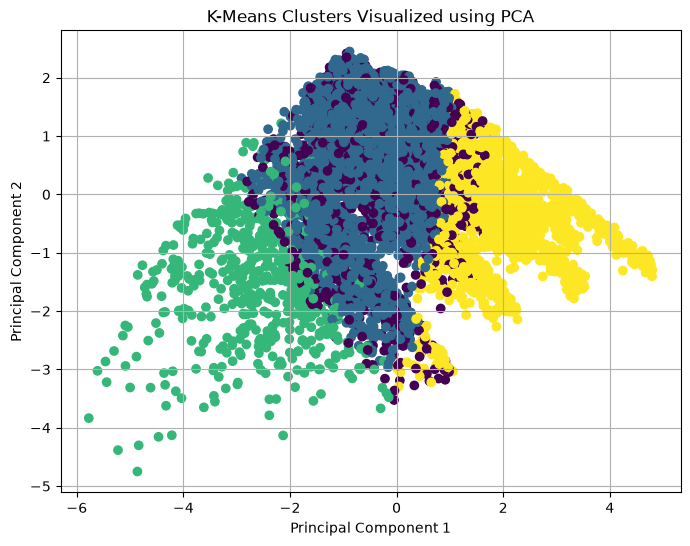

In [56]:
# PCA Visualization

from sklearn.decomposition import PCA

# Reduce dimentions from multiple features to 2 dimentions

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(y_means)

# Create a dataframe for visualization
pca_df = pd.DataFrame(reduced_data, columns=['PC1', 'PC2'])
pca_df['persona'] = df['persona']

# Add cluster labels
pca_df['persona'] = df['persona']

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['persona'], cmap='viridis')
plt.title('K-Means Clusters Visualized using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()


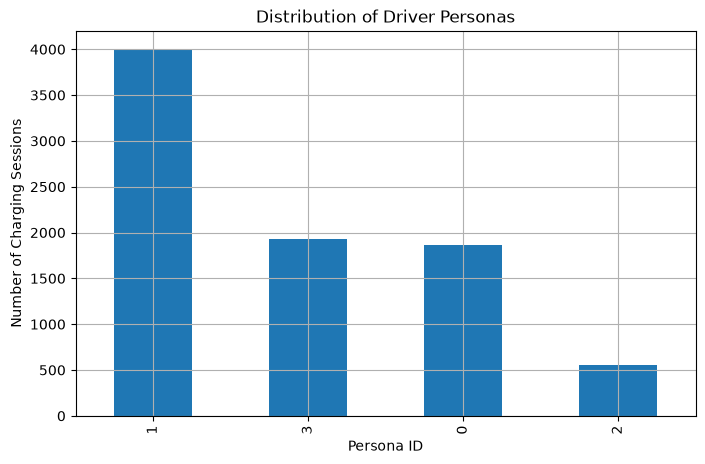

In [57]:
# Persona Distribution graph
plt.figure(figsize=(8,5))

df['persona'].value_counts().plot(kind='bar')

plt.title('Distribution of Driver Personas')

plt.xlabel('Persona ID')

plt.ylabel('Number of Charging Sessions')

plt.grid(True)

plt.show()

In [ ]:
# Random Forest

features = [
    'hour',
    'queue_length',
    'initial_soc',
    'traffic_density',
    'weather_condition',
    'day_of_week',

    'location_type',
    'vehicle_type',
    'is_weekend'
]

x = df[features]
y = df['charging_demand']


# Spliting the data
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size = 0.2,random_state = 42)

rf = RandomForestRegressor(n_estimators = 100,max_depth = 10,random_state = 42)

# Training random forest
rf.fit(x_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

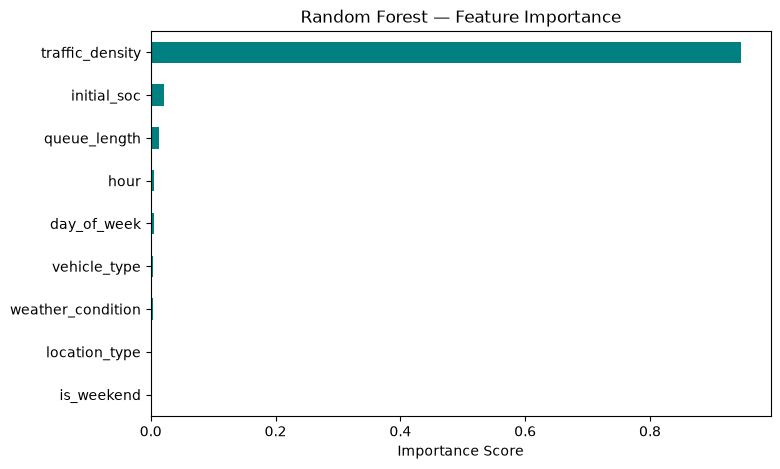

In [72]:
# Feature Importance
importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance.plot(kind='barh', color='teal')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

In [73]:
# XGBoost
xgb = XGBRegressor(n_estimators = 100,learning_rate = 0.1,max_depth = 6, random_state = 42)

#Training XGBoost
xgb.fit(x_train,y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [74]:
# Model Comparison using metrics

results = []
models = {
    'Random Forest':rf,
    'XGBoost':xgb
}

for name, model in models.items():
  pred = model.predict(x_test)
  mae = mean_absolute_error(y_test, pred)
  rmse = root_mean_squared_error(y_test, pred)
  r2 = r2_score(y_test, pred)

  results.append([name, mae, rmse, r2])


results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'R2'])
results_df






,Model,MAE,RMSE,R2
0,Random Forest,7.865370,9.558261,0.881961
1,XGBoost,7.901185,9.613200,0.880601


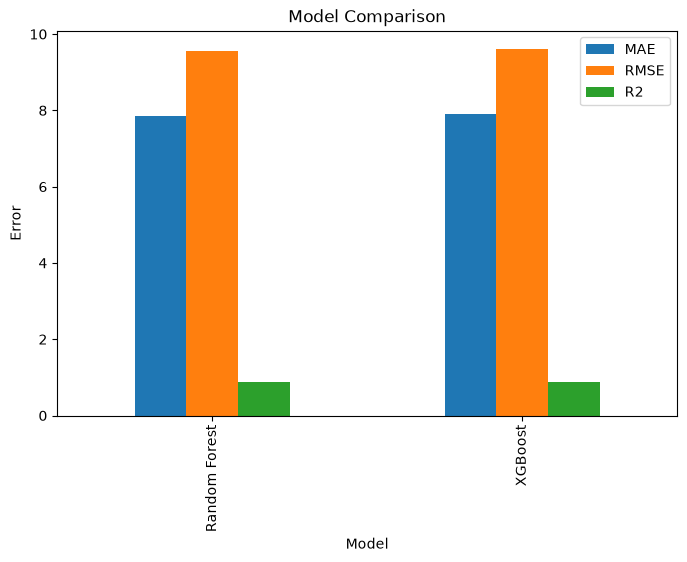

In [75]:
# Graph
comparison = results_df[['Model', 'MAE', 'RMSE', 'R2']]

comparison.set_index('Model').plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Model Comparison')

plt.ylabel('Error')

plt.show()

In [76]:
#cross validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, x, y, cv=5, scoring='r2')
print("Cross-Validation Scores:", scores)
print("Mean R2 Score:", scores.mean())

Cross-Validation Scores: [0.88574537 0.88213904 0.88035293 0.88557668 0.88681383]
Mean R2 Score: 0.8841255698279935


In [77]:
# Actual vs Predicted Analysis
# for random forest

rf_pred = rf.predict(x_test)

comparison_rf = pd.DataFrame({'Actual': y_test, 'Predicted': rf_pred})
comparison_rf.head(10)



,Actual,Predicted
3532,85.721649,81.932567
8239,65.222312,82.303414
4586,78.746789,80.892919
2795,17.950835,23.824184
5379,24.736213,21.025928
5903,68.854093,51.146082
1454,39.000704,29.981818
6282,103.212740,84.881006
743,103.587424,84.604400
1168,19.429369,24.422502


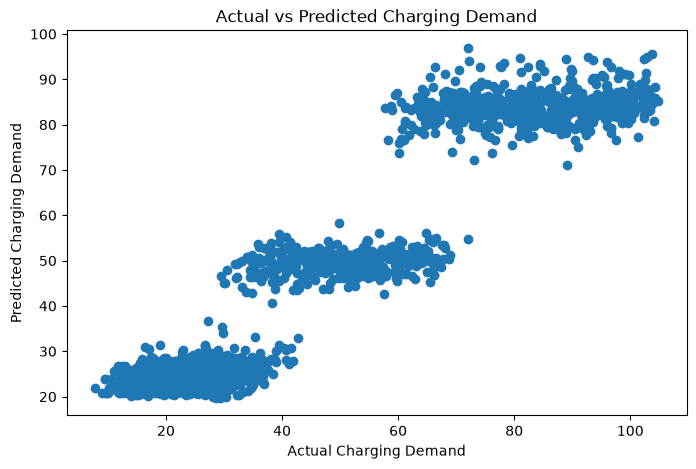

In [78]:
# Graph
plt.figure(figsize=(8,5))

plt.scatter(y_test, rf_pred)

plt.xlabel('Actual Charging Demand')

plt.ylabel('Predicted Charging Demand')

plt.title('Actual vs Predicted Charging Demand')

plt.show()

In [79]:
import joblib

In [80]:
joblib.dump(rf,"models/best_model.pkl")

['models/best_model.pkl']

In [81]:
joblib.dump(x,"models/scaler.pkl")

['models/scaler.pkl']

In [82]:
joblib.dump(encoders,"models/label_encoders.pkl")

['models/label_encoders.pkl']

In [85]:
print(df["vehicle_type"].unique())

[2 1 0]


In [87]:
print(encoders["vehicle_type"].classes_)

['Bus' 'Car' 'Two-Wheeler']


In [88]:
print(encoders["weather_condition"].classes_)
print(encoders["traffic_density"].classes_)
print(encoders["location_type"].classes_)
print(encoders["day_of_week"].classes_)

['Clear' 'Cloudy' 'Rainy']
['High' 'Low' 'Medium']
['Highway' 'Urban']
['Friday' 'Monday' 'Saturday' 'Sunday' 'Thursday' 'Tuesday' 'Wednesday']


In [90]:
type(x)

pandas.DataFrame